# Cats versus dogs - No need to run. Just explain  the code
- We are working with smaller dataset


In [83]:
# tensorflow==2.18.0
# tensorflow-datasets==4.9.7
# matplotlib==3.10.1
# pandas==2.2.3
# opencv-python==4.11.0.86
# scikit-learn==1.6.1
# jupyter==1.1.1


# 1. Import Python modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import PIL
import pathlib

from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Dropout, Flatten,Activation, BatchNormalization,MaxPooling2D
from tensorflow.keras import datasets, layers, models
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

In [84]:
# 2- Data-Constants
IMAGE_WIDTH=128
IMAGE_HEIGHT=128
IMAGE_CHANNELS=3

In [87]:
# 2. Load dataset¶
# data_dir = pathlib.Path("../input/microsoft-catsvsdogs-dataset/PetImages")
data_dir_path = "temp/data_cats_dogs_small/"
data_dir = pathlib.Path(data_dir_path)

print(f"data_dir: {data_dir}")
data_dir_list = list(data_dir.glob('*/*.jpg'))
print(f"Total image files: {len(data_dir_list)}")
print(f"1st 5 images: {data_dir_list[:5]}")

data_dir: temp\data_cats_dogs_small
Total image files: 1020
1st 5 images: [WindowsPath('temp/data_cats_dogs_small/cats/cat.4001.jpg'), WindowsPath('temp/data_cats_dogs_small/cats/cat.4002.jpg'), WindowsPath('temp/data_cats_dogs_small/cats/cat.4003.jpg'), WindowsPath('temp/data_cats_dogs_small/cats/cat.4004.jpg'), WindowsPath('temp/data_cats_dogs_small/cats/cat.4005.jpg')]


In [88]:
dogs = list(data_dir.glob('dogs/*'))
dogs[:5]

[WindowsPath('temp/data_cats_dogs_small/dogs/dog.4001.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4002.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4003.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4004.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4005.jpg')]

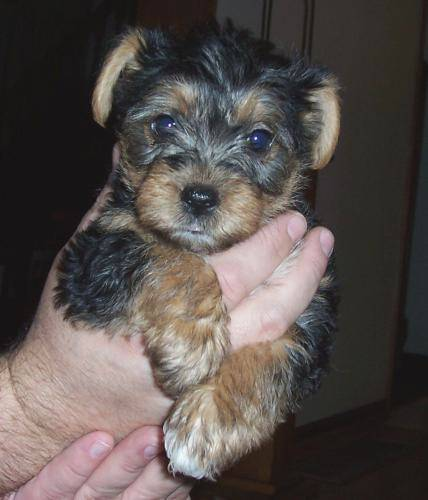

In [89]:
PIL.Image.open(str(dogs[1]))

In [90]:
cats = list(data_dir.glob('cats/*'))
cats[:5]

[WindowsPath('temp/data_cats_dogs_small/cats/cat.4001.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4002.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4003.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4004.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4005.jpg')]

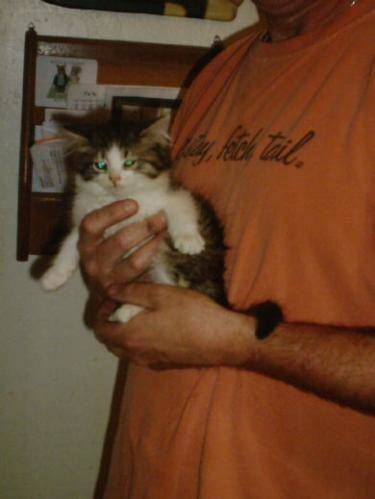

In [49]:
PIL.Image.open(str(cats[1]))

           images  CATEGORIES
0    cat.4001.jpg           0
1    cat.4002.jpg           0
2    cat.4003.jpg           0
3    cat.4004.jpg           0
4    cat.4005.jpg           0
..            ...         ...
495  cat.4496.jpg           0
496  cat.4497.jpg           0
497  cat.4498.jpg           0
498  cat.4499.jpg           0
499  cat.4500.jpg           0

[500 rows x 2 columns]
###################
           images  CATEGORIES
0    dog.4001.jpg           1
1    dog.4002.jpg           1
2    dog.4003.jpg           1
3    dog.4004.jpg           1
4    dog.4005.jpg           1
..            ...         ...
495  dog.4496.jpg           1
496  dog.4497.jpg           1
497  dog.4498.jpg           1
498  dog.4499.jpg           1
499  dog.4500.jpg           1

[500 rows x 2 columns]
$$$$$$$$$$$$$$$$$$$$$$$$$
         images  CATEGORIES
0  cat.4001.jpg           0
1  cat.4002.jpg           0
2  cat.4003.jpg           0
3  cat.4004.jpg           0
4  cat.4005.jpg           0
%%%%%%%%%%%%%%%%%%

<Axes: xlabel='CATEGORIES'>

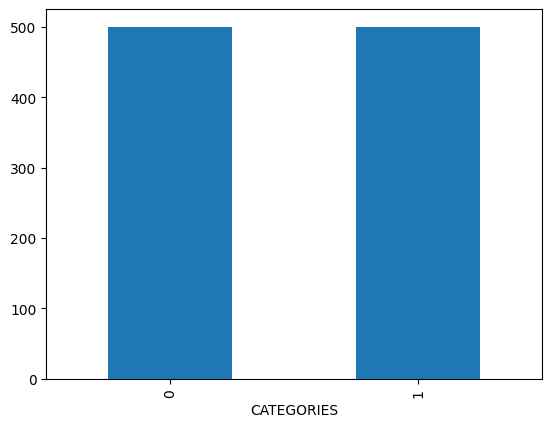

In [92]:
# Lets do EDA in one snippet of code. This can be broken down as series af cells
images_cats_path = data_dir_path + "/cats"
images_cats = os.listdir(images_cats_path) 

CATEGORIES = []

for image_name in images_cats:
    class_name = image_name.split('.')[0]  # cat.588.jpg
    CATEGORIES.append(0 if class_name=='cat' else 1)

df_cats = pd.DataFrame({"images": images_cats, "CATEGORIES": CATEGORIES})
print(df_cats)

print("###################")
images_dogs_path = data_dir_path + "/dogs"
images_dogs = os.listdir(images_dogs_path)

CATEGORIES = []

for image_name in images_dogs:
    class_name = image_name.split('.')[0]  # dog.588.jpg
    CATEGORIES.append(0 if class_name=='cat' else 1)

df_dogs = pd.DataFrame({"images": images_dogs, "CATEGORIES": CATEGORIES})
print(df_dogs)

print("$$$$$$$$$$$$$$$$$$$$$$$$$")
df= pd.concat([df_cats, df_dogs])
print(df.head())

print("%%%%%%%%%%%%%%%%%%%%%%%%%%")
print(df.tail())

print("^^^^^^^^^^^^^^^^^^^^^^^")
print(df.describe())

print("&&&&&&&&&&&&&&&&&&&&&")
print(df["CATEGORIES"].value_counts())

print("**************************")
df["CATEGORIES"].value_counts().plot.bar() # cat should be balanced

In [93]:
# Lets see the dimensions of all the images. (image_width,image_height, channels)
shapes = []

for image in df_cats["images"]: 
    # path = os.path.join("/kaggle/working/train",image)
    path = os.path.join(images_cats_path,image)
    image_array = plt.imread(path)
    shapes.append(image_array.shape)

for image in df_dogs["images"]: 
    # path = os.path.join("/kaggle/working/train",image)
    path = os.path.join(images_dogs_path,image)
    image_array = plt.imread(path)
    shapes.append(image_array.shape)
    
print(pd.Series(shapes).value_counts())


(375, 499, 3)    122
(374, 500, 3)    122
(333, 499, 3)     15
(499, 375, 3)     10
(332, 500, 3)     10
                ... 
(279, 481, 3)      1
(499, 347, 3)      1
(407, 500, 3)      1
(499, 414, 3)      1
(158, 250, 3)      1
Name: count, Length: 623, dtype: int64


In [94]:
# 3. Read Pets images from disk into numpy array using opencv
pet_images_dict = {
    'cats': list(data_dir.glob('cats/*')),
    'dogs': list(data_dir.glob('dogs/*')),
}

pet_labels_dict = {
    'cats': 0,
    'dogs': 1,
}

In [95]:
pet_images_dict['dogs'][:5]

[WindowsPath('temp/data_cats_dogs_small/dogs/dog.4001.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4002.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4003.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4004.jpg'),
 WindowsPath('temp/data_cats_dogs_small/dogs/dog.4005.jpg')]

In [96]:
pet_images_dict['cats'][:5]

[WindowsPath('temp/data_cats_dogs_small/cats/cat.4001.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4002.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4003.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4004.jpg'),
 WindowsPath('temp/data_cats_dogs_small/cats/cat.4005.jpg')]

In [97]:
X, Y = [], []

for pet_name, images in pet_images_dict.items():
    print(pet_name)
    for image in images:
        img = cv2.imread(str(image))
        if isinstance(img,type(None)): 
            print('image not found') # NOTE: can be commented out if o/p is large
            continue
            
        elif ((img.shape[0] >= IMAGE_HEIGHT) and  (img.shape[1] >=IMAGE_WIDTH)): # only read certain dim images
            resized_img = cv2.resize(img,(IMAGE_WIDTH,IMAGE_HEIGHT))
            X.append(resized_img)
            Y.append(pet_labels_dict[pet_name])
        else:
            print("Invalid Image") # NOTE: can be commented out if o/p is large
            continue
print("#########################")
# Lets look at one image
print(f"shape of 1st image:{X[0].shape}" ) # (IMAGE_HEIGHT,IMAGE_WIDTH, channel)
print(X[0])

cats
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
dogs
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
Invalid Image
#########################
shape of 1st image:(128, 128, 3)
[[[ 47  45  54]
  [124 111 125]
  [120 118 142]
  ...
  [102  90 101]
  [ 95  87  95]
  [ 39  35  39]]

 [[ 46  46  55]
  [150 142 153]
  [164 165 175]
  ...
  [168 155 136]
  [123 113 106]
  [ 32  28  28]]

 [[ 42  46  52]
  [171 168 177]
  [246 249 249]
  ...
  [204 186 136]
  [149 138 118]
  [ 26  21  21]]

 ...

 [[ 50  42  55]
  [173 166 178]
  [ 23  23  12]
  ...
  [190 183 165]
  [132 125 118]
  [ 30  28  27]]

 [[ 55  49  55]
  [ 95  86  99]
  [ 38  37  27]
  ...
  [ 79  72  66]
  [ 76  72  68]
  [ 28  27  26]]

 [[ 12  11   9]
  [ 13   9  17]
  [  5   5   0]
  ...
  [ 16  10  12]
  [  8   8   

In [98]:
print(len(X))
print(len(Y))

977
977


In [99]:
X = np.array(X)
Y = np.array(Y)

In [100]:
# 4. Train Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42)
print(len(X_train),len(Y_train))
print(len(X_test),len(Y_test))

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

732 732
245 245
(732, 128, 128, 3) (732,)
(245, 128, 128, 3) (245,)


## 2 models
### Model1

Here we use model with 3 conv layer.

In [101]:
# 5. Build convolutional neural network and train it

model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid'), # 2 because we have cat and dog classes
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)                   │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_31               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,942,273 (49.37 MB)

 Trainable params: 12,940,801 (49.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [102]:
history=model.fit(X_train, Y_train, epochs=10) # with 10 epochs took 3 minutes.

# In following it shaows 2 values:
# 1st value: Loss ( lower the better)
# 2nd value show acuracy (Higher the better)
model.evaluate(X_test,Y_test) 

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 534ms/step - accuracy: 0.4917 - loss: 1.6599
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 554ms/step - accuracy: 0.6716 - loss: 0.7029
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 649ms/step - accuracy: 0.7964 - loss: 0.5081
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 557ms/step - accuracy: 0.8095 - loss: 0.4416
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 567ms/step - accuracy: 0.8546 - loss: 0.3327
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 548ms/step - accuracy: 0.8850 - loss: 0.3105
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 577ms/step - accuracy: 0.8808 - loss: 0.2985
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 571ms/step - accuracy: 0.9129 - loss: 0.2176
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 543ms/step - accuracy: 0.9264 - loss: 0.1687
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 546ms/step - accuracy: 0.9628 - loss: 0.1142
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6118 - loss: 0.8946 


[0.899017870426178, 0.6285714507102966]

In [105]:
#saving model so we do not have to train again.
model_path = "temp/saved_models/"

model_name =  os.path.join(model_path, "model1_catdog_style1_10epoch.keras")
weight_name = os.path.join(model_path, "model1_catdog_style1_10epoch.weights.h5")

model.save(model_name)

# model.save_weights(weight_name) 

In [106]:
#Now we load the model
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model(model_name)

# model.load_weights(weight_name)

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.76      0.67       123
           1       0.67      0.49      0.57       122

    accuracy                           0.63       245
   macro avg       0.64      0.63      0.62       245
weighted avg       0.64      0.63      0.62       245



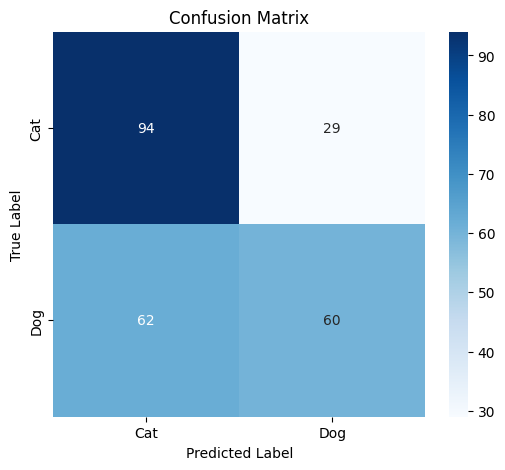

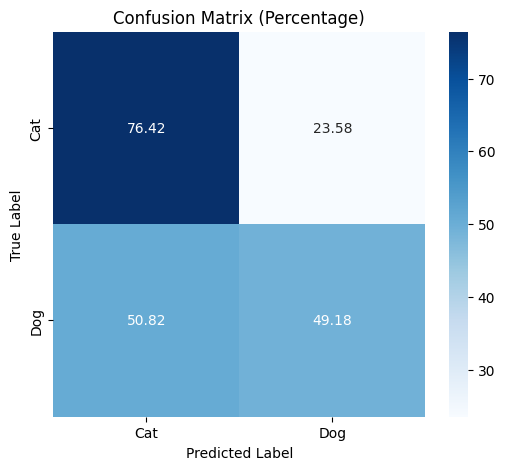

In [107]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = [0 if element < 0.5 else 1 for element in y_pred]

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred_classes)

# Print classification report
print("Classification Report:\n", classification_report(Y_test, y_pred_classes))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# Normalize confusion matrix to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot confusion matrix with percentages
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()


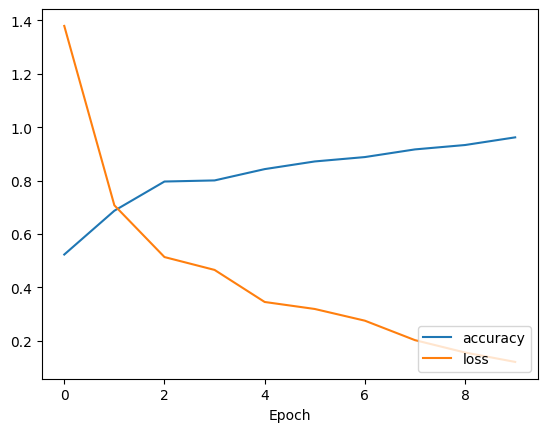

In [108]:
# Evaluate the model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label = 'loss')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

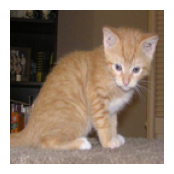

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Raw Prediction Output: [[0.00976947]]
Predicted Class: 0 Name: cat


In [111]:
# Lets make prediction on 1 image

# Define class labels
classes = ["cat", "dog"]

# Load and preprocess image
fileImage = Image.open(data_dir_path + "cats/cat.4003.jpg").convert("RGB")
fileImage = fileImage.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.LANCZOS)

# Convert to NumPy array and reshape for model input
image = np.array(fileImage)
myimage = image.reshape(1, IMAGE_WIDTH, IMAGE_HEIGHT, 3) / 255.0  # Normalize to [0,1]

# Display the image
plt.figure(figsize=(4,2))
plt.imshow(image)
plt.axis('off')
plt.show()

# Make prediction
my_predicted_image = model.predict(myimage)  # Output: [[0.1, 0.9]] for softmax

# Get the class with the highest probability
y_class = np.argmax(my_predicted_image)

# Print prediction result
print("Raw Prediction Output:", my_predicted_image)
print("Predicted Class:", y_class, "Name:", classes[y_class])


### Model 2
Lets improve above model1

- Added 4th Conv2D layer (256 filters) for deeper feature learning.
- Used LeakyReLU(alpha=0.1) instead of ReLU to avoid dead neurons.
- Adjusted Dropout: 0.2 in early layers to retain low-level features. 0.4 in deeper layers to prevent overfitting.
- Used SGD optimizer with momentum (0.9) to improve convergence stability.
- Used padding='same' in Conv2D to maintain spatial dimensions.

In [112]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import LeakyReLU

model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3, 3), padding='same', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Second Convolutional Layer
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Third Convolutional Layer
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    # Fourth Convolutional Layer
    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),

    # Fully Connected Layer
    Dense(512),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification (cat vs. dog)
])

# Use SGD optimizer with momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Show model summary
model.summary()


c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_32               │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_20 (LeakyReLU)           │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_33               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_21 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_34               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_22 (LeakyReLU)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_35               │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_23 (LeakyReLU)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 8,782,017 (33.50 MB)

 Trainable params: 8,780,033 (33.49 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [113]:
history=model.fit(X_train, Y_train, epochs=10) # with 10 epochs took 3 minutes.

# In following it shaows 2 values:
# 1st value: Loss ( lower the better)
# 2nd value show acuracy (Higher the better)
model.evaluate(X_test,Y_test) 

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 687ms/step - accuracy: 0.5570 - loss: 0.8721
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 647ms/step - accuracy: 0.5930 - loss: 0.7993
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 680ms/step - accuracy: 0.6241 - loss: 0.7020
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 680ms/step - accuracy: 0.6475 - loss: 0.6842
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 646ms/step - accuracy: 0.6677 - loss: 0.6264
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 637ms/step - accuracy: 0.6855 - loss: 0.6351
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 626ms/step - accuracy: 0.7150 - loss: 0.5865
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 635ms/step - accuracy: 0.7357 - loss: 0.5521
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 632ms/step - accuracy: 0.7535 - loss: 0.5116
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 636ms/step - accuracy: 0.6871 - loss: 0.5887
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5126 - loss: 1.6242


[1.6037471294403076, 0.5102040767669678]

In [114]:
#saving model so we do not have to train again.
model_name =  "model2_catdog_style1_10epoch.keras"
weight_name = "model2_catdog_style1_10epoch.weights.h5"

model.save(model_name)

# model.save_weights(weight_name) 

In [115]:
#Now we load the model
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model(model_name)

# model.load_weights(weight_name)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.03      0.06       123
           1       0.50      0.99      0.67       122

    accuracy                           0.51       245
   macro avg       0.65      0.51      0.37       245
weighted avg       0.65      0.51      0.36       245



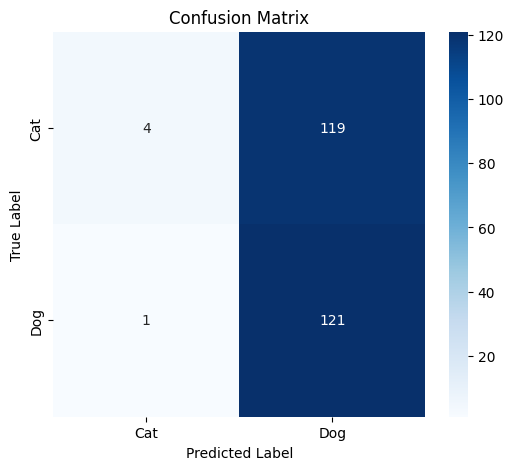

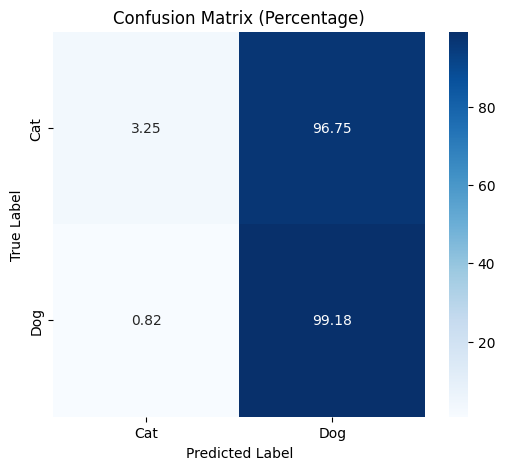

In [116]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = [0 if element < 0.5 else 1 for element in y_pred]

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred_classes)

# Print classification report
print("Classification Report:\n", classification_report(Y_test, y_pred_classes))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# Normalize confusion matrix to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot confusion matrix with percentages
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()


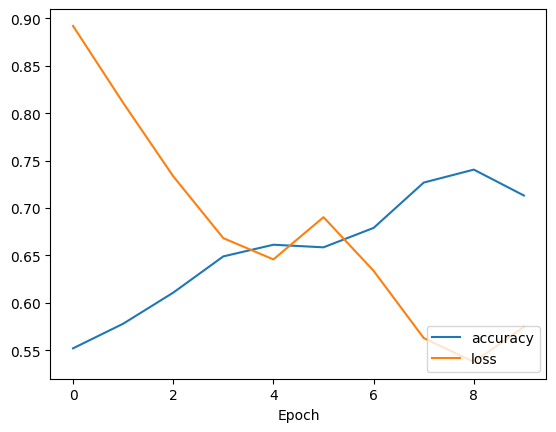

In [117]:
# Evaluate the model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label = 'loss')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Thoughts
- accuracy increased slightly
- You can improve the model with larger datasets